### Import and Helpers

In [ ]:
import sys, json
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from dataset.statistics import read_split, generate_report

In [ ]:
def load_stats(ds_dir):
    fp = Path(ds_dir) / "statistic.json"
    if not fp.exists():
        generate_report(ds_dir)
    return json.loads(fp.read_text())

def match(meta, flt):
    for k, allowed in flt.items():
        v = meta.get(k)
        allowed = allowed if isinstance(allowed, (list, tuple, set)) else [allowed]
        hit = any(x in allowed for x in v) if isinstance(v, list) else v in allowed
        if not hit:
            return False
    return True

# Dataset Dashboard
1. Given dataset, display the data in prettier look (\n displayed as real newline etc)
2. Costumized filter that helps us fine the useful info

In [ ]:
DATA_DIR  = "../../dataset/CPT/Nitin-10k-jac-functions"
SPLIT     = ["train", "valid"]
FORMAT    = "jsonl"


# Preview

In [3]:
N_DISPLAY = 10
FILTER    = {
    "class": ["graph"]
} # tags in the meta, can be a list

In [4]:
for split in SPLIT:
    print("=" * 80)
    print(f"SPLIT: {split}")
    print("=" * 80)
    shown = matched = 0
    for rec in read_split(DATA_DIR, split):
        if not match(rec.get("meta", {}), FILTER):
            continue
        matched += 1
        if shown < N_DISPLAY:
            shown += 1
            print(f"\n--- [{split} #{shown}] meta={rec.get('meta', {})} ---")
            print(rec.get("text", ""))
    print(f"\n>>> {split}: {matched} record(s) matched {FILTER}; displayed {shown}\n")


SPLIT: train

--- [train #1] meta={'source': 'code', 'format': 'jac', 'class': 'graph'} ---
# written in jac
"""
    This method is used to construct the path from start edge to goal edge
    """
def _reconstruct_path(came_from: Any, start: Any, goal: Any) -> object {
    current = goal;
    path = [];
    while (current != start) {
        path.append(current);
        current = came_from.get(current);
    }
    path.append(start);
    path.reverse();
    return path;
}


--- [train #2] meta={'source': 'code', 'format': 'jac', 'class': 'graph'} ---
# Jac lang
""" Count occurences of root in node. """
def get_occurences(`node: Any, `root: Any) -> object {
    count = 0;
    for c in `node {
        if (c == `root) {
            count += 1;
        }
    }
    return count;
}


--- [train #3] meta={'source': 'code', 'format': 'jac', 'class': 'graph'} ---
# Language: Jac
"""
    Using an ast.FunctionDef node, create a items list node that
    will give us the passed in args by name.

   

# Statistics

In [5]:
BAR   = ["class"] # columns you want to plot as a bar chart, in SFT "task_type" is worth seeing

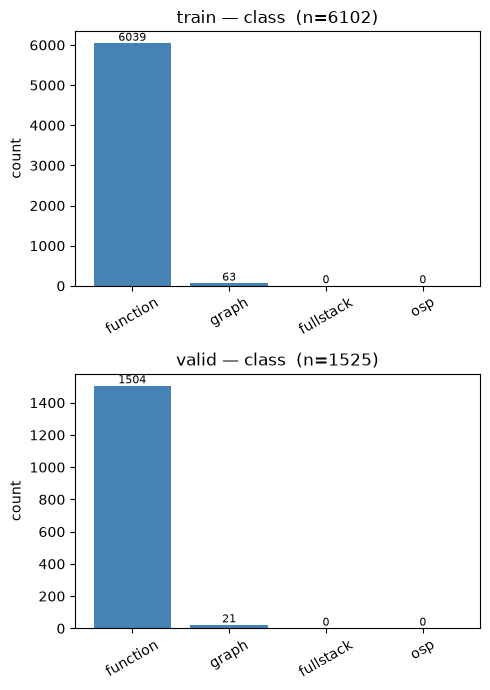

In [6]:
stats = load_stats(DATA_DIR)

n_rows, n_cols = len(SPLIT), len(BAR)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)

for i, split in enumerate(SPLIT):
    props = stats[split]["property"]
    for j, field in enumerate(BAR):
        ax = axes[i][j]
        items = sorted(props[field].items(), key=lambda kv: -kv[1])
        labels, values = zip(*items) if items else ([], [])
        bars = ax.bar(labels, values, color="steelblue")
        ax.set_title(f"{split} — {field}  (n={stats[split]['count']})")
        ax.set_ylabel("count")
        ax.tick_params(axis="x", rotation=30)
        for b, v in zip(bars, values):
            ax.text(b.get_x() + b.get_width() / 2, v, str(v),
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
